In [ ]:
# typical libraries...
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

# for importing and working with texts
import requests
import re
import string

# pytorch stuff
from torch.utils.data import Dataset, DataLoader
import torch
import torch.nn as nn
import torch.nn.functional as F


from torchinfo import summary

import matplotlib_inline.backend_inline
matplotlib_inline.backend_inline.set_matplotlib_formats('svg')

In [2]:
# get raw text from internet (The Time Machine... yeah I use it a lot :P  )
text = requests.get('https://www.gutenberg.org/files/35/35-0.txt').text
# character strings to replace with space
strings2replace = [ '\r\n\r\nâ\x80\x9c','â\x80\x9c','â\x80\x9d','\r\n','â\x80\x94','â\x80\x99','â\x80\x98','_', ]

# use regular expression (re) to replace those strings with space
for str2match in strings2replace:
  text = re.compile(r'%s'%str2match).sub(' ',text)

# remove non-ASCII characters and numbers, and make lower-case
text = re.sub(r'[^\x00-\x7F]+', ' ', text)
text = re.sub('\d+','',text).lower()

# split into words with >1 letter
words = re.split(f'[{string.punctuation}\s]+',text)
words = [item.strip() for item in words if item.strip()]
words = [item for item in words if len(item)>1]

# create the vocabulary (lexicon)
vocab  = sorted(set(words))
nWords = len(words)
nVocab = len(vocab)

# encoder/decoder look-up-tables (as python dictionaries)
word2idx = {w:i for i,w in enumerate(vocab)}
idx2word = {i:w for i,w in enumerate(vocab)}

# show a few keys in the dictionary
print(f'The book contains {nWords:,} words, {nVocab:,} of which are unique and comprise the vocab.')
print(f'\n\nFirst 10 vocab words:\n',list(word2idx.keys())[:10])

The book contains 30,698 words, 4,589 of which are unique and comprise the vocab.


First 10 vocab words:
 ['abandon', 'abandoned', 'able', 'abnormally', 'abominable', 'abominations', 'about', 'above', 'abruptly', 'absence']


In [3]:
# parameters for dataset
context_length = 8 # context length
stride = 2 # skipping

# initialize
inputs  = []
targets = []

# overlapping sequences of context_length
for i in range(0,nWords-context_length,stride):

  # get a few words
  in_seq   = words[i  : i+context_length  ]
  targ_seq = words[i+1: i+context_length+1]

  # append to the lists
  inputs.append([word2idx[w] for w in in_seq])
  targets.append([word2idx[w] for w in targ_seq])

print(inputs[123])
print(targets[123])

[1342, 4304, 4119, 342, 4296, 3388, 1474, 131]
[4304, 4119, 342, 4296, 3388, 1474, 131, 209]


In [4]:
# a closer look:
print('Inputs: ',inputs[4])
print('Targets:',targets[4])
print('')
print('Inputs :',inputs[5])
print('Targets:',targets[5])

Inputs:  [2416, 131, 2172, 506, 4451, 783, 2167, 2005]
Targets: [131, 2172, 506, 4451, 783, 2167, 2005, 4042]

Inputs : [2172, 506, 4451, 783, 2167, 2005, 4042, 2416]
Targets: [506, 4451, 783, 2167, 2005, 4042, 2416, 2006]


In [5]:
# we need each list to be a tensor
torch.tensor(inputs[4])

tensor([2416,  131, 2172,  506, 4451,  783, 2167, 2005])

In [6]:
# create a class for a dataset
class WordDataset(Dataset):
  def __init__(self, text, word2idx, context_length=8, stride=4):

    # initialize
    self.inputs  = []
    self.targets = []
    self.word2idx = word2idx  # stored locally in the object

    # overlapping sequences of context_length
    for i in range(0,len(text)-context_length,stride):

      # get a few words
      in_seq   = text[i : i+context_length]
      targ_seq = text[i+1 : i+context_length+1]

      # append to the lists
      self.inputs.append(torch.tensor([word2idx[w] for w in in_seq]))
      self.targets.append(torch.tensor([word2idx[w] for w in targ_seq]))

  def __len__(self):
    return len(self.inputs)

  def __getitem__(self, idx):
    return self.inputs[idx], self.targets[idx]


# create an instance!
context_length = 6 # context length
stride = 3 # skipping over tokens
text_dataset = WordDataset(words,word2idx,context_length,stride)

text_dataset[4]

(tensor([4451,  783, 2167, 2005, 4042, 2416]),
 tensor([ 783, 2167, 2005, 4042, 2416, 2006]))

In [7]:
# also need a dataloader
dataloader = DataLoader(
                text_dataset,
                batch_size = 32, # 2 for looking; 32 for training
                shuffle    = True,
                drop_last  = True
            )

# let's have a look at the indices
X,y = next(iter(dataloader))
print('Inputs:')
print(X), print('')

print('Targets:')
print(y), print('\n\n\n')

# and the words
print('Inputs in words (first batch):')
print([idx2word[item.item()] for item in X[0]])
print('')

print('Targets in words (first batch):')
print([idx2word[item.item()] for item in y[0]])

Inputs:
tensor([[ 339, 3353, 3444, 4303, 1122, 4042],
        [3132,  801,  230, 4450,  230, 4408],
        [1835, 4296, 4042, 1018, 4041, 3230],
        [  91, 2069, 4051, 4408, 3715, 2041],
        [ 501, 4042, 3053, 2731, 4042, 4544],
        [1448,  501, 2651, 1453, 3138, 3385],
        [1640, 2608, 1832, 1815, 4119,  503],
        [4042, 1716, 2731, 3692, 2287, 4249],
        [4043,  675, 1484, 1852, 1453, 2041],
        [4065, 2744, 2608, 1080, 4119, 2305],
        [4450, 2740, 4042, 4069,  916, 2731],
        [4170, 2163, 4042, 1659, 3388, 1474],
        [2593, 1963, 4039, 2780, 2812, 4408],
        [4549, 1021,  137, 2041, 4042, 1258],
        [1977, 3474, 2435, 1815,  339,  781],
        [1861,  769, 2609,  506, 2012, 4042],
        [2669, 2572, 1815,  196, 4304, 2069],
        [3406, 2302, 2731, 4045,  551, 3712],
        [2698,  763, 1845,  735, 4047, 4042],
        [2382,  113, 4133, 2718, 1572, 2382],
        [3321, 3699, 3347, 4058, 1815, 3468],
        [ 137, 4408, 1910,

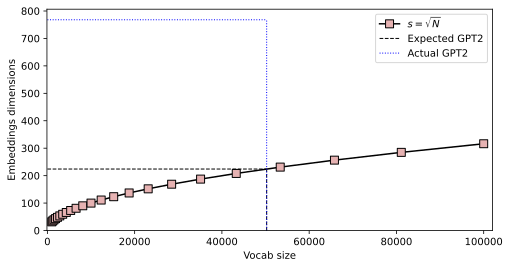

In [8]:
# exploring dimensionality based on vocab sizes

# vocab sizes
N = np.logspace(np.log10(1000),np.log10(100000),23)

# heuristic for non-LLM models like word2vec or glove:
embdim = np.sqrt(N)

# parameters for GPT2
gpt2dims = [ 50257,768 ]

plt.figure(figsize=(8,4))

# heuristic line
plt.plot(N,embdim,'ks-',markersize=8,markerfacecolor=[.9,.7,.7],label=r'$s = \sqrt{N}$')

# expected embedding dim for GPT2
plt.plot([gpt2dims[0],gpt2dims[0]],[0,np.sqrt(gpt2dims[0])],'k--',linewidth=1,label='Expected GPT2')
plt.plot([0,gpt2dims[0]],[np.sqrt(gpt2dims[0]),np.sqrt(gpt2dims[0])],'k--',linewidth=1)

# actual GPT2 embedding
plt.plot([gpt2dims[0],gpt2dims[0]],[0,gpt2dims[1]],'b:',linewidth=1,label='Actual GPT2')
plt.plot([0,gpt2dims[0]],[gpt2dims[1],gpt2dims[1]],'b:',linewidth=1)

plt.gca().set(xlabel='Vocab size',ylabel='Embeddings dimensions',
              xlim=[-100,N[-1]+2000],ylim=[0,None])
plt.legend()
plt.show()

In [9]:
# dimensionality of embedding space (arbitrarily set to 100)
embeddingDimension = 100

# create a random embedding
embedding_layer = nn.Embedding(nVocab,embeddingDimension)

# let's see its size
embedding_layer.weight.shape

torch.Size([4589, 100])

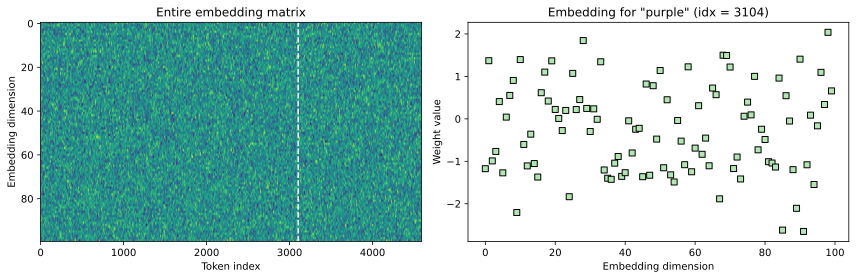

In [10]:
# what does it look like?

_,axs = plt.subplots(1,2,figsize=(12,4))
axs[0].imshow(embedding_layer.weight.detach().T,aspect='auto',vmin=-1,vmax=1)
axs[0].set(ylabel='Embedding dimension',xlabel='Token index',title='Entire embedding matrix')

# pick a word at random
aRandomWord = np.random.choice(vocab)

# plot its embedding
axs[1].plot(embedding_layer.weight.detach()[word2idx[aRandomWord],:],'ks',markerfacecolor=[.7,.9,.7])
axs[0].axvline(word2idx[aRandomWord],color='w',linestyle='--')
axs[1].set(xlabel='Embedding dimension',ylabel='Weight value',title=f'Embedding for "{aRandomWord}" (idx = {word2idx[aRandomWord]})')

plt.tight_layout()
plt.show()

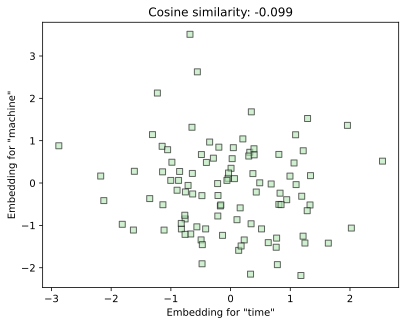

In [11]:
# embeddings for closely related words
word1 = 'time'
word2 = 'machine'

# their embeddings
embed1 = embedding_layer.weight.detach()[word2idx[word1],:]
embed2 = embedding_layer.weight.detach()[word2idx[word2],:]

# cosine similiarity between them
cosSim = torch.dot(embed1,embed2)/(torch.norm(embed1)*torch.norm(embed2))

# vizualize
plt.plot(embed1,embed2,'ks',markerfacecolor=[.7,.9,.7],alpha=.6)
plt.gca().set(xlabel=f'Embedding for "{word1}"',ylabel=f'Embedding for "{word2}"',
              title=f'Cosine similarity: {cosSim:.3f}')
plt.show()

In [13]:
class EmbeddingModel(nn.Module):
  def __init__(self, vocab_size, embedding_dim, context_size):
    super(EmbeddingModel, self).__init__()

    # embedding layer
    self.embeddings = nn.Embedding(vocab_size, embedding_dim)

    # linear layers
    self.linear1 = nn.Linear(context_size * embedding_dim, 128)
    self.linear2 = nn.Linear(128, vocab_size)

  def forward(self, inputs):

    # extract and flatten embeddings [batch_size, context_size * embedding_dim]
    embeds = self.embeddings(inputs).view(inputs.shape[0],-1)

    # fully connected layers
    out = F.relu(self.linear1(embeds))
    out = self.linear2(out)

    # log softmax for classification (note: NLLLoss expects logprobs as inputs)
    log_probs = F.log_softmax(out, dim=1)
    return log_probs


# create a model instance!
model = EmbeddingModel(vocab_size=nVocab, embedding_dim=embeddingDimension, context_size=context_length)
print(model)

# apply Xavier weight distribution
for param in model.parameters():
  if param.dim()>1: # also excludes biases
    nn.init.xavier_normal_(param)

EmbeddingModel(
  (embeddings): Embedding(4589, 100)
  (linear1): Linear(in_features=600, out_features=128, bias=True)
  (linear2): Linear(in_features=128, out_features=4589, bias=True)
)


In [14]:
# let's test the model

X,y = next(iter(dataloader))
modelOut = model(X)

print('Input to model:')
print(X), print('')

print(f'Output from model (size: {list(modelOut.detach().shape)}):')
print(modelOut)

Input to model:
tensor([[4119, 2435, 3388, 4042, 1105, 4042],
        [4042, 2674, 2731, 2417, 1794, 2397],
        [1019, 3693,  137, 1234, 2783, 4042],
        [4041,  916, 4133, 2420, 1629, 2731],
        [1868, 2468,  319,    2, 4119, 3843],
        [4042, 1930,  137,  833,  351, 2470],
        [4042,   92, 2186,  185, 2064, 4119],
        [1815, 1742,  944,  137,  944, 2163],
        [3235, 4042, 1242, 2347, 4042,  542],
        [1453, 3584, 1572, 4042, 3069, 1944],
        [ 251, 2731, 1929, 2334,  137, 4537],
        [2324, 2041, 2608, 1835, 3116,   96],
        [1048,  255, 3501, 2003, 1868, 2685],
        [2997, 2731,  132,  137, 2731, 4315],
        [4058, 1815, 2309, 1901, 2985, 2368],
        [2608, 2637, 4047, 4042, 2458, 3438],
        [4042, 4419, 3716,  469, 4408, 4059],
        [1557, 2731, 4073, 3056,  501, 2186],
        [2608, 1450, 4463, 2740,  221, 1815],
        [4581, 2468, 4252, 4036, 2470, 2041],
        [ 232, 4249, 4042,  457, 2573, 3628],
        [3130, 411

In [15]:
# log soft-max output:
print(modelOut.detach()[0])
print('')

# shouldn't the sum be 1?
print(f'Log softmax sum = {modelOut.detach()[0].sum():.3f}')

# ah, it's *log* softmax :D
print(f'exp(log(softmax)) sum = {torch.exp(modelOut.detach()[0]).sum():.3f}')

tensor([-8.3932, -8.5227, -8.3968,  ..., -8.3723, -8.3854, -8.4635])

Log softmax sum = -38697.719
exp(log(softmax)) sum = 1.000


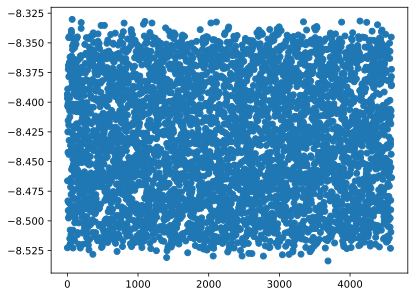

In [18]:
plt.plot(modelOut[0].detach(),'o');